# Pretraining Evaluation
Compare Phase 1 models (kl/vq · mamba/transformers) and Phase 2 (JEPA) on a downstream EEG dataset.

The dataset is selectable in the **Config** cell via `DATASET` (BCI2A, PHYSIONETMI, BCI2020, FACED, SEEDV, SLEEPEDF, TUAB, KARAONE, CHISCO). Channels are auto-remapped to a common 19-channel layout and the class count is derived from the data.

**Sections**
1. Setup & data loading
2. Reconstruction comparison (5 s window)
3. Temporal consistency — k-NN label agreement
4. UMAP

In [18]:
import sys
sys.path.insert(0, '/home/infres/yrothlin-24/EEG-VAE')

import warnings; warnings.filterwarnings('ignore')
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import DataLoader, Subset

print('torch:', torch.__version__)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)

torch: 2.9.1+cu128
device: cuda


## Config

In [19]:
CKPT_ROOT = Path('/projects/EEG-foundation-model/RECH202/EEG-VAE/checkpoints')

# Checkpoint layout (cf. main_pretraining.model_subdir):
#   kl + attention → kl/transformers
#   kl + mamba     → kl/mamba
#   vq + attention → vq/transformers/q{n}
#   vq + mamba     → vq/mamba/q{n}
CKPT = {
    'kl_mamba':        CKPT_ROOT / 'pretraining/kl/mamba/pretraining_final.pt',
    'vq_mamba':        CKPT_ROOT / 'pretraining/vq/mamba/q8/pretraining_final.pt',
    'vq_transformers': CKPT_ROOT / 'pretraining/vq/transformers/q8/pretraining_final.pt',
    'jepa':            CKPT_ROOT / 'jepa/mamba/q8/jepa_final.pt',
}

# (sequence_block, model_type) for each Phase 1 checkpoint
PHASE1_SPEC = {
    'kl_mamba':        ('mamba',     'kl'),
    'vq_mamba':        ('mamba',     'vq'),
    'vq_transformers': ('attention', 'vq'),
}

# ── Dataset selection ─────────────────────────────────────────────────────────
# CustomDataset auto-detects the dataset from the lmdb filename and remaps all
# channels to a common 19-channel layout, so switching dataset = switching path.
# Just change DATASET below to any key of the registry.
DATASET    = 'PHYSIONETMI'
TESTS_ROOT = Path('/projects/EEG-foundation-model/RECH202/tests')

# class_names=None → derived automatically from the integer labels present.
DATASETS = {
    'BCI2A':       dict(path=TESTS_ROOT / 'BCI2A/bci2a.lmdb',
                        class_names=['Left hand', 'Right hand', 'Feet', 'Tongue'], fs=200),
    'PHYSIONETMI': dict(path=TESTS_ROOT / 'PHYSIONETMI/physionetmi.lmdb', class_names=None, fs=200),
    'BCI2020':     dict(path=TESTS_ROOT / 'BCI2020/bci2020.lmdb',         class_names=None, fs=200),
    'FACED':       dict(path=TESTS_ROOT / 'FACED/faced.lmdb',             class_names=None, fs=200),
    'SEEDV':       dict(path=TESTS_ROOT / 'SEEDV/seedv.lmdb',             class_names=None, fs=200),
    'SLEEPEDF':    dict(path=TESTS_ROOT / 'SLEEPEDF/sleepedf.lmdb',       class_names=None, fs=200),
    'TUAB':        dict(path=TESTS_ROOT / 'TUAB/tuab.lmdb',               class_names=None, fs=200),
    'KARAONE':     dict(path=TESTS_ROOT / 'KARAONE/karaone.lmdb',         class_names=None, fs=200),
    'CHISCO':      dict(path=TESTS_ROOT / 'CHISCO/chisco.lmdb',           class_names=None, fs=200),
}

_ds_cfg     = DATASETS[DATASET]
DATA_PATH   = str(_ds_cfg['path'])
CLASS_NAMES = _ds_cfg['class_names']     # may be None → resolved after data loading
FS          = _ds_cfg['fs']              # Hz
N_SAMPLES   = 500                        # samples used for k-NN / UMAP

# Base model config shared by all Phase 1 checkpoints
BASE_CFG = dict(
    in_channels=19, out_channels=19,
    adapted_channels=64, adaptor_layers=2,
    z_channels=16, embed_dim=16,
    ch=64, ch_mult=[1, 2, 4],
    num_res_blocks=2, attn_resolutions=[],
    resolution=None, dropout=0.0,
    resamp_with_conv=True, tanh_out=False,
    use_checkpoint=False, criss_cross_patch_size=200,
)
VQ_EXTRA       = dict(vq_num_embeddings=512, vq_commitment_cost=0.25, vq_decay=0.99)
PREDICTOR_CFG  = dict(embed_dim=16, predictor_embed_dim=128, num_heads=4, num_layers=4, max_seq_len=2048)

print(f'Dataset: {DATASET}  →  {DATA_PATH}  {"✓" if Path(DATA_PATH).exists() else "✗ missing"}')
print('Available checkpoints:')
for name, path in CKPT.items():
    print(f'  {name:<16}: {"✓" if path.exists() else "✗ missing"}  {path}')

Dataset: PHYSIONETMI  →  /projects/EEG-foundation-model/RECH202/tests/PHYSIONETMI/physionetmi.lmdb  ✓
Available checkpoints:
  kl_mamba        : ✓  /projects/EEG-foundation-model/RECH202/EEG-VAE/checkpoints/pretraining/kl/mamba/pretraining_final.pt
  vq_mamba        : ✓  /projects/EEG-foundation-model/RECH202/EEG-VAE/checkpoints/pretraining/vq/mamba/q8/pretraining_final.pt
  vq_transformers : ✓  /projects/EEG-foundation-model/RECH202/EEG-VAE/checkpoints/pretraining/vq/transformers/q8/pretraining_final.pt
  jepa            : ✓  /projects/EEG-foundation-model/RECH202/EEG-VAE/checkpoints/jepa/mamba/q8/jepa_final.pt


## 1 · Data loading

In [20]:
import lmdb, pickle
from eeg_preprocessing.loaders import CustomDataset

def get_subject_ids(lmdb_path):
    env = lmdb.open(str(lmdb_path), subdir=False, readonly=True, lock=False)
    with env.begin(write=False) as txn:
        ids = pickle.loads(txn.get(b'__subject_ids__'))
    env.close()
    return list(ids)

subject_ids = get_subject_ids(DATA_PATH)
dataset     = CustomDataset(DATA_PATH, subject_ids=subject_ids, channel_mode='mapped')
print(f'{DATASET}: {len(dataset)} samples — {len(subject_ids)} subjects')

# Build local_dataset_index → subject_id mapping
local_to_subject = {}
local_idx = 0
for sid in dataset.subject_ids:
    for start, end in dataset.sub2range.get(sid, []):
        for _ in range(max(0, end - start)):
            local_to_subject[local_idx] = sid
            local_idx += 1

rng     = torch.Generator().manual_seed(42)
indices = torch.randperm(len(dataset), generator=rng)[:N_SAMPLES].tolist()
loader  = DataLoader(Subset(dataset, indices), batch_size=64, shuffle=False, num_workers=2)

# Subject label for each sample in the subset
sample_subjects = np.array([local_to_subject[i] for i in indices])

x_batch, y_batch = next(iter(loader))
x_batch = x_batch.float()

# Resolve number of classes / class names from the labels actually present in
# the subset (works for any dataset). An explicit CLASS_NAMES from the registry
# is respected; otherwise generic names are generated.
subset_labels = []
for _, y in loader:
    subset_labels.append(y)
subset_labels = torch.cat(subset_labels).numpy()
N_CLASSES     = int(subset_labels.max()) + 1
if CLASS_NAMES is None or len(CLASS_NAMES) < N_CLASSES:
    CLASS_NAMES = [f'class {i}' for i in range(N_CLASSES)]

print(f'Batch shape: {x_batch.shape}   classes: {N_CLASSES}  {CLASS_NAMES}')
print(f'Subjects in subset: {sorted(set(sample_subjects))}')

PHYSIONETMI: 9838 samples — 109 subjects
Batch shape: torch.Size([64, 19, 800])   classes: 4  ['class 0', 'class 1', 'class 2', 'class 3']
Subjects in subset: [np.str_('S001'), np.str_('S002'), np.str_('S003'), np.str_('S004'), np.str_('S005'), np.str_('S006'), np.str_('S007'), np.str_('S008'), np.str_('S009'), np.str_('S010'), np.str_('S011'), np.str_('S012'), np.str_('S013'), np.str_('S014'), np.str_('S015'), np.str_('S016'), np.str_('S017'), np.str_('S018'), np.str_('S019'), np.str_('S020'), np.str_('S021'), np.str_('S022'), np.str_('S023'), np.str_('S024'), np.str_('S025'), np.str_('S026'), np.str_('S027'), np.str_('S028'), np.str_('S029'), np.str_('S030'), np.str_('S031'), np.str_('S032'), np.str_('S033'), np.str_('S034'), np.str_('S035'), np.str_('S036'), np.str_('S037'), np.str_('S038'), np.str_('S039'), np.str_('S040'), np.str_('S041'), np.str_('S042'), np.str_('S043'), np.str_('S044'), np.str_('S045'), np.str_('S046'), np.str_('S047'), np.str_('S048'), np.str_('S049'), np.str_

## 2 · Model loading

In [21]:
import importlib
import eeg_vae.modules.vector_quantizer
import eeg_vae.modules.autoencoder_vq
import eeg_vae.eeg_vae
import eeg_vae.jepa
import eeg_vae

importlib.reload(eeg_vae.modules.vector_quantizer)
importlib.reload(eeg_vae.modules.autoencoder_vq)
importlib.reload(eeg_vae.eeg_vae)
importlib.reload(eeg_vae.jepa)
importlib.reload(eeg_vae)

from eeg_vae import EEGVAE
from eeg_vae.jepa import JEPAEncoder, EEGJEPA
from eeg_vae.modules.predictor import EEGPredictor

def _detect_ch_from_sd(sd, prefix='autoencoder'):
    """Infer ch from encoder conv_in weight shape [ch, adapted_channels, 3]."""
    w = sd.get(f'{prefix}.encoder.conv_in.weight')
    return int(w.shape[0]) if w is not None else 64

def _detect_n_quantizers_from_sd(sd, prefix='autoencoder'):
    n = 0
    while f'{prefix}.quantize.quantizers.{n}.embedding' in sd:
        n += 1
    return max(1, n)

def load_phase1(name, path, sequence_block, model_type='kl'):
    ckpt = torch.load(path, map_location='cpu')
    sd   = ckpt['model_state_dict']
    ch   = _detect_ch_from_sd(sd)
    cfg  = {**BASE_CFG, 'model_type': model_type, 'sequence_block': sequence_block, 'ch': ch}
    if model_type == 'vq':
        n_q = _detect_n_quantizers_from_sd(sd)
        cfg.update({**VQ_EXTRA, 'vq_n_quantizers': n_q})
        print(f'  {name}: ch={ch}, n_quantizers={n_q}')
    else:
        print(f'  {name}: ch={ch}')
    model = EEGVAE(**cfg)
    model.load_state_dict(sd)
    return model.eval().to(DEVICE)

def load_jepa(jepa_path, _vae_path=None):
    """Load JEPA directly from its own checkpoint — no VQ checkpoint needed,
    since the JEPA state_dict already contains all encoder weights."""
    jepa_sd = torch.load(jepa_path, map_location='cpu')['model_state_dict']

    # Detect arch from the JEPA state_dict itself
    ch  = _detect_ch_from_sd(jepa_sd, prefix='context_encoder')
    n_q = _detect_n_quantizers_from_sd(jepa_sd, prefix='context_encoder')
    print(f'  jepa: ch={ch}, n_quantizers={n_q}')

    # Build architecture with the detected params, then load weights
    vae_cfg = {**BASE_CFG, 'model_type': 'vq', 'sequence_block': 'mamba',
               'ch': ch, **VQ_EXTRA, 'vq_n_quantizers': n_q}
    eeg_vae_model    = EEGVAE(**vae_cfg)
    context_encoder  = JEPAEncoder(eeg_vae_model)
    predictor        = EEGPredictor(**PREDICTOR_CFG)
    model            = EEGJEPA(context_encoder=context_encoder, predictor=predictor)
    model.load_state_dict(jepa_sd)
    return model.eval().to(DEVICE)

@torch.no_grad()
def encode(model, x, is_jepa=False):
    x = x.float().to(DEVICE)
    z = model.context_encoder(x) if is_jepa else model.encode(x).mode()
    return z.mean(dim=-1).cpu()

print('Loading...')
models = {}
for name, (sequence_block, model_type) in PHASE1_SPEC.items():
    if CKPT[name].exists():
        models[name] = load_phase1(name, CKPT[name], sequence_block, model_type)
if CKPT['jepa'].exists():
    models['jepa'] = load_jepa(CKPT['jepa'])

print('Ready:', list(models.keys()))

Loading...
  kl_mamba: ch=128
  vq_mamba: ch=128, n_quantizers=8
  vq_transformers: ch=128, n_quantizers=8
  jepa: ch=128, n_quantizers=8
Ready: ['kl_mamba', 'vq_mamba', 'vq_transformers', 'jepa']


## 2 · Reconstruction comparison (3 channels: FZ / CZ / PZ)
One column per model, channels stacked vertically. The original is overlaid (faint) on each reconstruction.

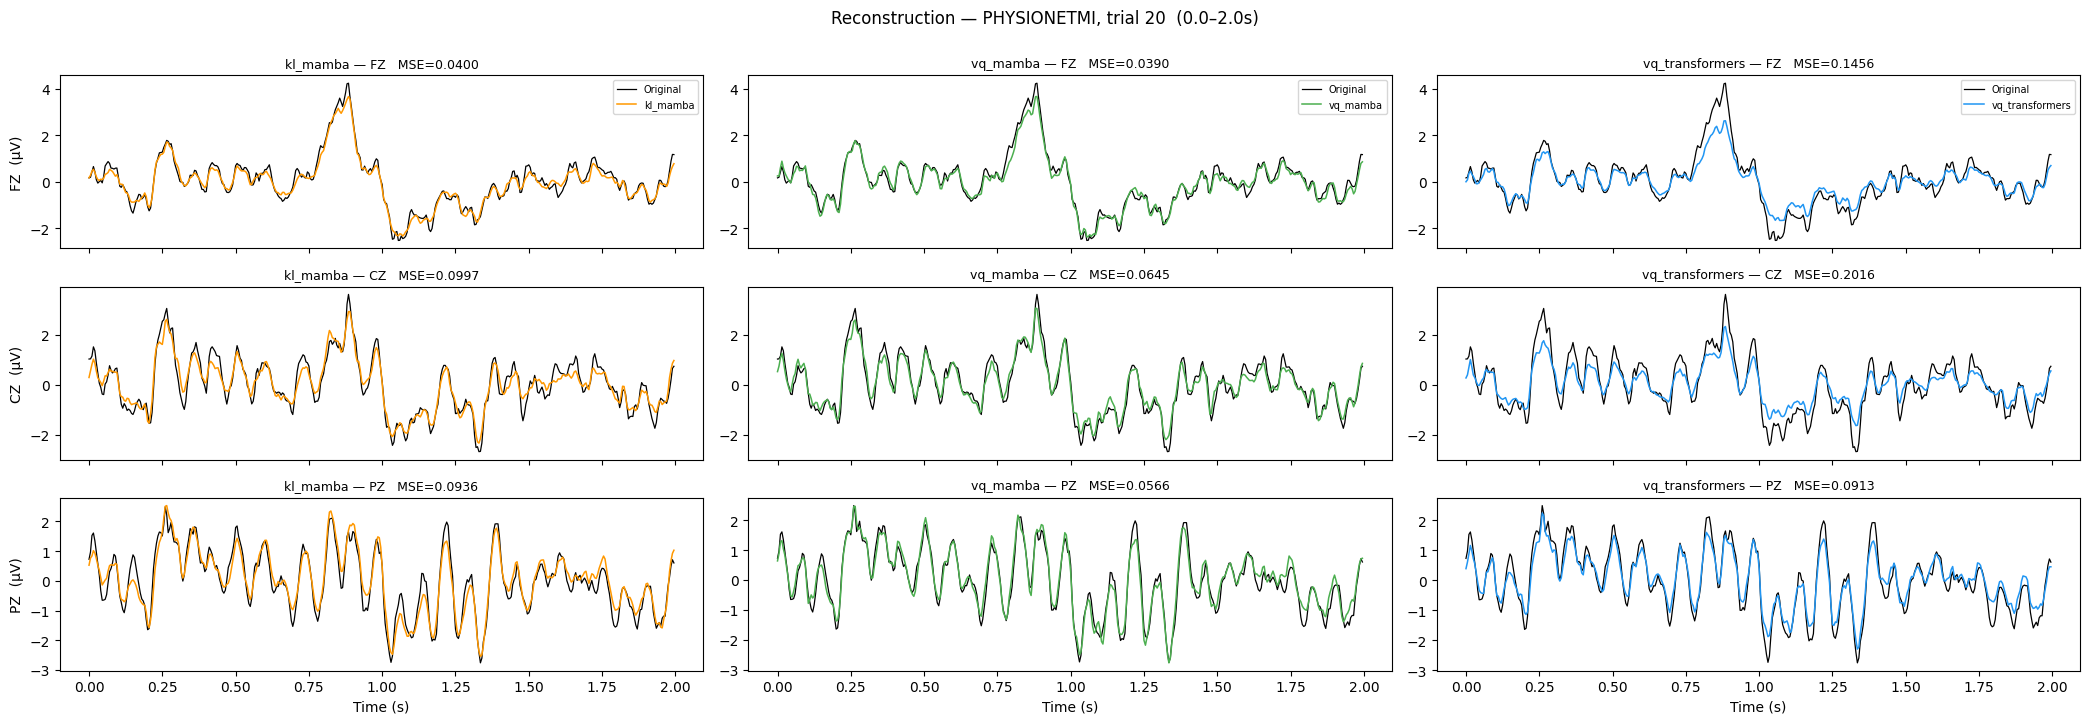

In [22]:
# ── Choose which trial / channels / time window to reconstruct ────────────────
RECON_IDX = 20               # index into the evaluation subset (0 .. N_SAMPLES-1)
CH_IDS    = [16, 17, 18]    # FZ, CZ, PZ in the 19-ch standard layout (TARGET_CHS)
WIN_START = 0.0             # start of the displayed window, in seconds
WIN_SEC   = 2.0           # length of the displayed window in seconds (None = full trial)

TARGET_CHS = ["FP1","FP2","F3","F4","C3","C4","P3","P4","O1","O2",
              "F7","F8","T7","T8","P7","P8","FZ","CZ","PZ"]

# One reconstruction colour per model (shared with the PSD figure)
MODEL_COLORS = {'kl_mamba': '#FF9800', 'vq_mamba': '#4CAF50', 'vq_transformers': '#2196F3'}

# Fetch any trial from the subset (not limited to the first batch)
x_one = dataset[indices[RECON_IDX]][0].float().unsqueeze(0)

# Time-window slice (in samples)
T_total = x_one.shape[-1]
s0 = int(WIN_START * FS)
s1 = T_total if WIN_SEC is None else min(T_total, s0 + int(WIN_SEC * FS))
s0 = max(0, min(s0, T_total - 1))
t  = np.arange(s0, s1) / FS          # seconds, for the x-axis

recon_models = {k: v for k, v in models.items() if k != 'jepa'}
n_ch, n_md   = len(CH_IDS), len(recon_models)

# Pre-compute reconstructions once per model (on the full trial), then crop for display
recons = {}
for name, model in recon_models.items():
    with torch.no_grad():
        recons[name] = model.reconstruct(x_one.to(DEVICE)).cpu()

# Grid: one column per model, one row per channel (channels stacked vertically)
fig, axes = plt.subplots(n_ch, n_md, figsize=(7 * n_md, 2.4 * n_ch),
                         sharex=True, squeeze=False)

for col, (name, rec) in enumerate(recons.items()):
    color = MODEL_COLORS.get(name, f'C{col}')
    for row, ch in enumerate(CH_IDS):
        ax   = axes[row, col]
        orig = x_one[0, ch, s0:s1].numpy()
        pred = rec[0, ch, s0:s1].numpy()
        mse  = float(((pred - orig) ** 2).mean())
        ax.plot(t, orig, color='k',   lw=0.9, label='Original')
        ax.plot(t, pred, color=color, lw=1.1, label=name)
        ax.set_title(f'{name} — {TARGET_CHS[ch]}   MSE={mse:.4f}', fontsize=9)
        if col == 0:
            ax.set_ylabel(f'{TARGET_CHS[ch]}  (µV)')
        if row == 0:
            ax.legend(loc='upper right', fontsize=7)

for ax in axes[-1, :]:
    ax.set_xlabel('Time (s)')

win_txt = f'{t[0]:.1f}–{t[-1]:.1f}s' if len(t) else 'full'
fig.suptitle(f'Reconstruction — {DATASET}, trial {RECON_IDX}  ({win_txt})', fontsize=12, y=1.0)
plt.tight_layout()
Path('logs').mkdir(exist_ok=True)
plt.savefig('logs/reconstruction_comparison.png', dpi=150)
plt.show()

## 3b · Power Spectral Density comparison

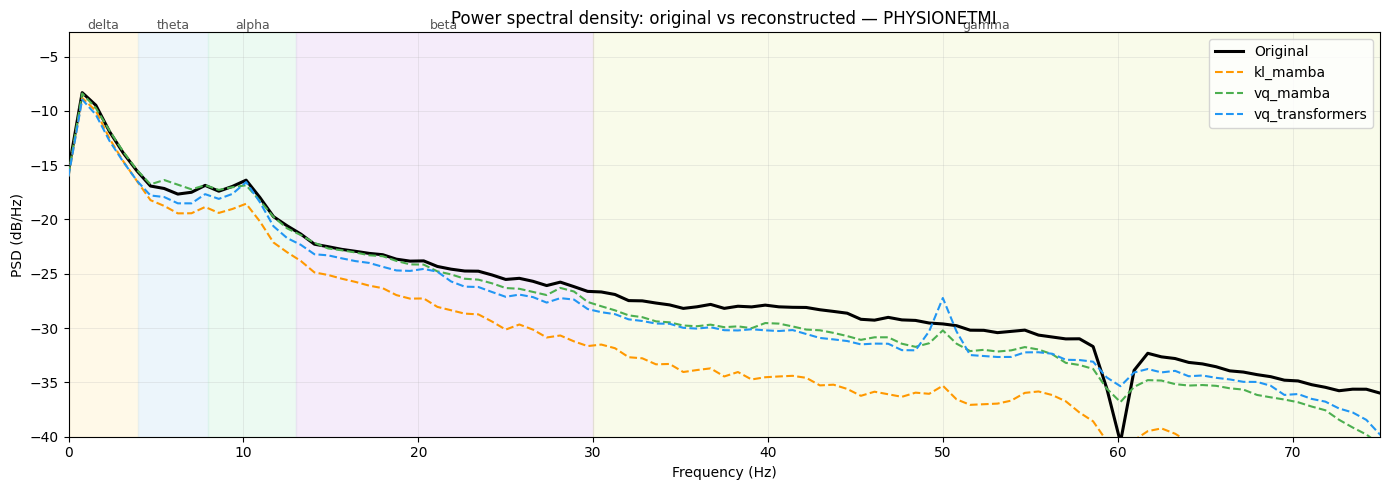

In [23]:
from scipy.signal import welch

# ── Frequency bands ───────────────────────────────────────────────────────────
BANDS = [
    ('delta', 0,   4,   '#FFF3CD', 0.45),
    ('theta', 4,   8,   '#D6EAF8', 0.45),
    ('alpha', 8,   13,  '#D5F5E3', 0.45),
    ('beta',  13,  30,  '#EBD5F5', 0.45),
    ('gamma', 30,  None,'#F0F4C3', 0.35),
]

SHOW_STD = False   # True → overlay ±1 std shaded bands (busier, harder to read)
Y_MIN    = -40     # lower limit of the PSD y-axis (dB/Hz)

def compute_psd(x_np):
    """x_np: (B, C, T)  →  freqs, mean_psd_dB (F,), std_psd_dB (F,)"""
    psds = []
    for b in range(x_np.shape[0]):
        for c in range(x_np.shape[1]):
            f, p = welch(x_np[b, c], fs=FS, nperseg=256)
            psds.append(p)
    psds = np.array(psds)                        # (B*C, F)
    mean_db = 10 * np.log10(psds.mean(axis=0) + 1e-12)
    std_db  = 10 * np.log10(psds + 1e-12).std(axis=0)
    return f, mean_db, std_db

# Compute PSD for original and all Phase 1 models on the full batch
x_np = x_batch.numpy()   # (B, 19, T)

psd_data = {'Original': compute_psd(x_np)}
for name, model in models.items():
    if name == 'jepa':
        continue
    with torch.no_grad():
        rec = model.reconstruct(x_batch.to(DEVICE)).cpu().numpy()
    psd_data[name] = compute_psd(rec)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

colors = {'Original': 'k', 'kl_mamba': '#FF9800', 'vq_mamba': '#4CAF50', 'vq_transformers': '#2196F3'}

f_ref  = psd_data['Original'][0]
f_max  = f_ref[-1]
x_hi   = min(75, f_max)

# Band shading (labels are drawn once, later, after the y-limits are known)
for label, flo, fhi, color, alpha in BANDS:
    ax.axvspan(flo, fhi if fhi is not None else f_max, color=color, alpha=alpha, zorder=0)

# PSD mean lines (Original solid+thick, reconstructions dashed to separate them)
for name, (f, mean_db, std_db) in psd_data.items():
    c  = colors.get(name, 'grey')
    lw = 2.2 if name == 'Original' else 1.5
    ls = '-' if name == 'Original' else '--'
    ax.plot(f, mean_db, color=c, lw=lw, ls=ls, label=name, zorder=3)
    if SHOW_STD:
        ax.fill_between(f, mean_db - std_db, mean_db + std_db, color=c, alpha=0.12, zorder=2)

ax.set_xlim(0, x_hi)
ax.set_ylim(bottom=Y_MIN)          # clip the y-axis at Y_MIN dB/Hz
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD (dB/Hz)')
ax.set_title(f'Power spectral density: original vs reconstructed — {DATASET}')
ax.legend(loc='upper right')
ax.grid(True, lw=0.4, alpha=0.4)

# Band labels — drawn exactly once, just above the top of the data
ymax = ax.get_ylim()[1]
for label, flo, fhi, *_ in BANDS:
    x1 = min(fhi if fhi is not None else x_hi, x_hi)
    if flo >= x_hi:
        continue
    ax.text((flo + x1) / 2, ymax, label, ha='center', va='bottom', fontsize=9, color='#555555')

plt.tight_layout()
plt.savefig('logs/psd_comparison.png', dpi=150)
plt.show()

## 3 · Temporal consistency
For each sample find its *k* nearest neighbours in the latent space and measure  
what fraction share the same class label.  
**Random baseline = 1 / N_CLASSES** (depends on the selected dataset). Higher → more semantically structured latent.

In [24]:
from sklearn.neighbors import NearestNeighbors

K = 10

all_z = {name: [] for name in models}
all_y = []
for x, y in loader:
    for name, model in models.items():
        all_z[name].append(encode(model, x, is_jepa=(name == 'jepa')))
    all_y.append(y)

all_y = torch.cat(all_y).numpy()
all_z = {name: torch.cat(zs).numpy() for name, zs in all_z.items()}
print(f'Encoded {len(all_y)} samples\n')

baseline = 1 / N_CLASSES
print(f'k-NN label consistency (k={K})   random baseline = {baseline:.3f}  ({N_CLASSES} classes)')
print('-' * 38)
results = {}
for name, Z in all_z.items():
    _, idx = NearestNeighbors(n_neighbors=K+1, metric='cosine', n_jobs=-1).fit(Z).kneighbors(Z)
    results[name] = (all_y[idx[:, 1:]] == all_y[:, None]).mean()
    print(f'  {name:<16}  {results[name]:.3f}')

Encoded 500 samples

k-NN label consistency (k=10)   random baseline = 0.250  (4 classes)
--------------------------------------
  kl_mamba          0.243
  vq_mamba          0.251
  vq_transformers   0.247
  jepa              0.266


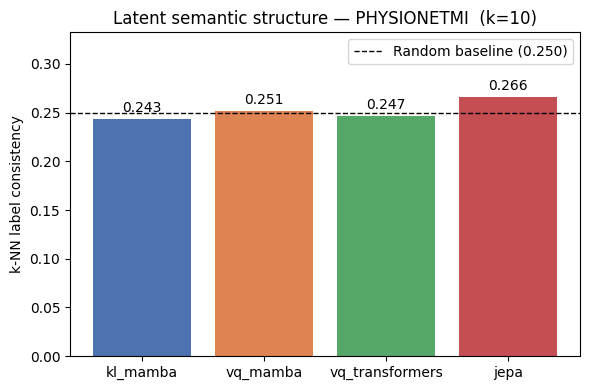

In [25]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(list(results.keys()), list(results.values()),
              color=['#4C72B0','#DD8452','#55A868','#C44E52'][:len(results)])
ax.axhline(baseline, color='k', ls='--', lw=1, label=f'Random baseline ({baseline:.3f})')
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set_ylim(0, max(max(results.values()), baseline) * 1.25)
ax.set_ylabel('k-NN label consistency')
ax.set_title(f'Latent semantic structure — {DATASET}  (k={K})')
ax.legend()
plt.tight_layout()
plt.savefig('logs/temporal_consistency.png', dpi=150)
plt.show()

## 5 · UMAP

**Pourquoi le UMAP ne montre pas de clusters nets par classe ?**
C'est **attendu** pour un modèle Phase 1 (reconstruction).
La loss de reconstruction optimise la fidélité du signal, pas la séparation des classes.
Le latent capture *comment bien reconstruire*, pas *quelle classe motrice*.

Ce qu'on peut espérer observer :
- **Par sujet** : clusters nets → le latent capture les signatures individuelles EEG (inter-subject variability). C'est typiquement ce que produit un bon modèle de reconstruction.
- **Par classe** : clusters nets → le latent capture l'intention motrice. C'est l'objectif du Phase 2 (JEPA) + fine-tuning.

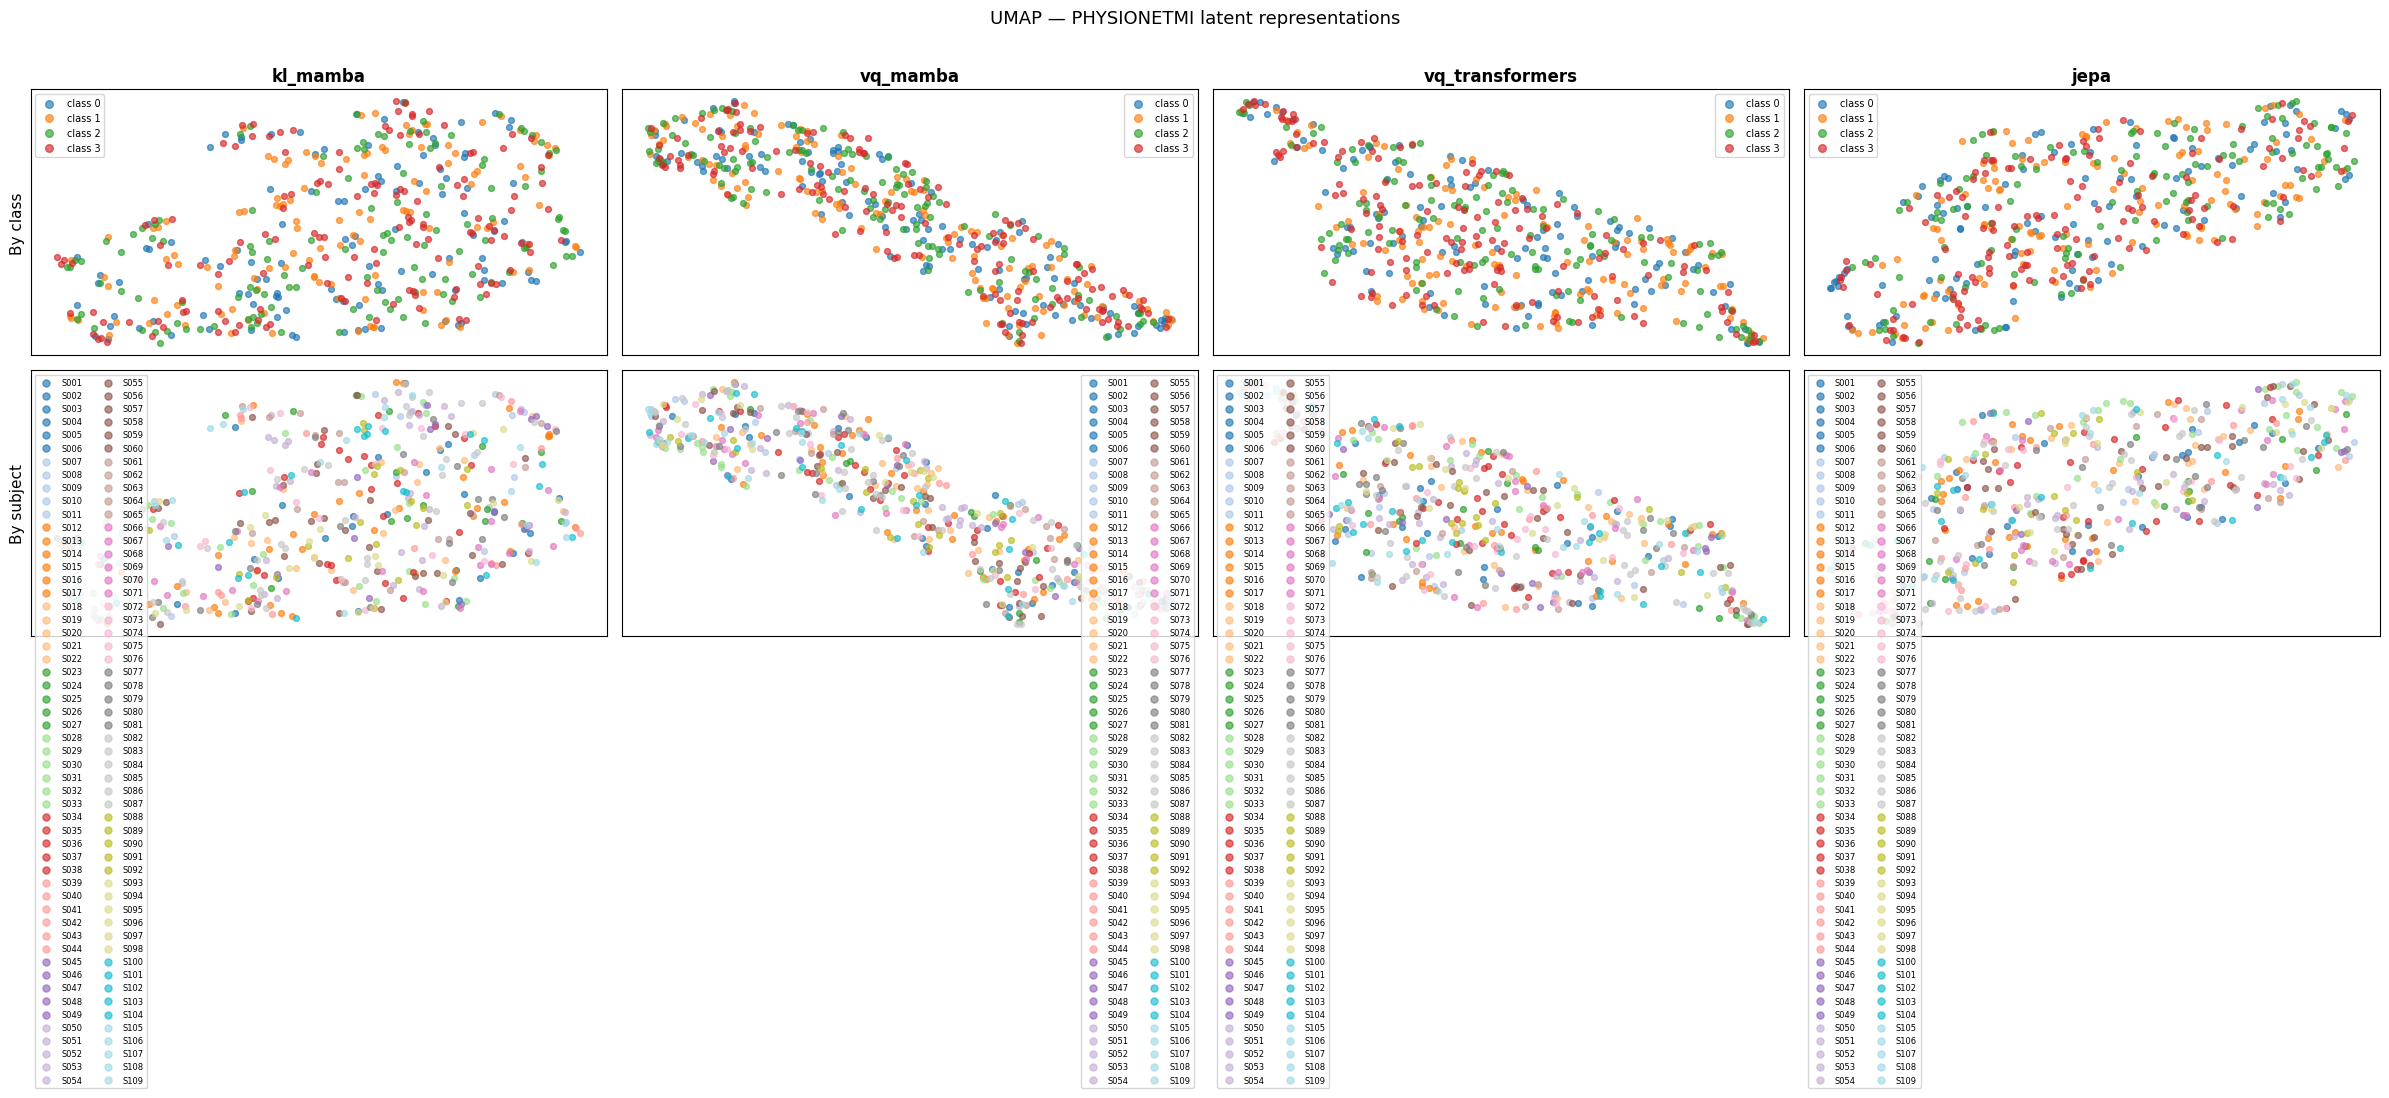

In [26]:
import umap

unique_subjects = sorted(set(sample_subjects))
n_subj   = len(unique_subjects)
subj2idx = {s: i for i, s in enumerate(unique_subjects)}
subj_int = np.array([subj2idx[s] for s in sample_subjects])

n_models      = len(all_z)
palette_class = plt.cm.tab10(np.arange(N_CLASSES) / 10)
palette_subj  = plt.cm.tab20(np.arange(n_subj) / max(n_subj, 1))

fig, axes = plt.subplots(2, n_models, figsize=(6 * n_models, 10))
if n_models == 1:
    axes = axes.reshape(2, 1)

for col, (name, Z) in enumerate(all_z.items()):
    Z2d = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42, verbose=False).fit_transform(Z)

    # Row 0 — by class
    ax = axes[0, col]
    for cls in range(N_CLASSES):
        mask = all_y == cls
        ax.scatter(Z2d[mask, 0], Z2d[mask, 1], c=[palette_class[cls]],
                   label=CLASS_NAMES[cls], alpha=0.65, s=18, rasterized=True)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.legend(fontsize=7, markerscale=1.3, loc='best')
    ax.set_xticks([]); ax.set_yticks([])
    if col == 0:
        ax.set_ylabel('By class', fontsize=11)

    # Row 1 — by subject
    ax = axes[1, col]
    for si, sid in enumerate(unique_subjects):
        mask = subj_int == si
        ax.scatter(Z2d[mask, 0], Z2d[mask, 1], c=[palette_subj[si]],
                   label=sid, alpha=0.65, s=18, rasterized=True)
    ax.legend(fontsize=6, markerscale=1.2, loc='best', ncol=2)
    ax.set_xticks([]); ax.set_yticks([])
    if col == 0:
        ax.set_ylabel('By subject', fontsize=11)

plt.suptitle(f'UMAP — {DATASET} latent representations', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('logs/umap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()